# Taller - Segmentando el Mundo: Binarización y Reconocimiento de Formas

In [41]:
!pip install --upgrade pip

In [2]:
!pip install opencv-python

In [42]:
import cv2

In [43]:
import numpy as np

In [44]:
import matplotlib.pyplot as plt

In [45]:
from google.colab.patches import cv2_imshow

In [46]:
def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

## Cargar imagen

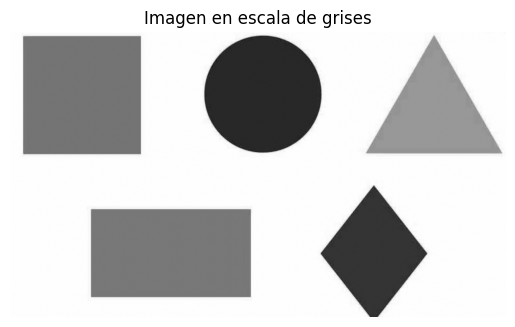

In [221]:
imagen = cv2.imread('media/figuras.jpg')

#Se asegura que la imagen este en escala de grises
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

#mostrar imagen
show_image(imagen_gris, "Imagen en escala de grises")

## Segmentacion binaria con umbral fijo

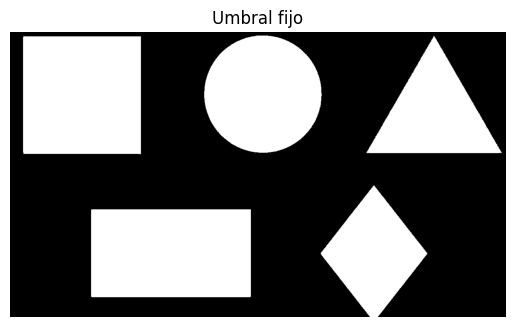

In [210]:
umbral, imagen_binaria = cv2.threshold(
    imagen_gris, 200, 255,
    cv2.THRESH_BINARY_INV)

show_image(imagen_binaria, "Umbral fijo")

## Segmentacion binaria con umbral adaptativo

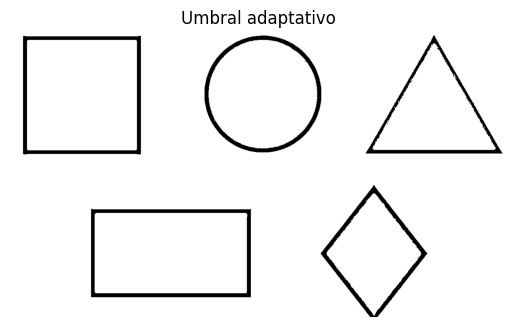

In [212]:
imagen_binaria_umbral_adaptativo = cv2.adaptiveThreshold(
    imagen_gris, 250,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    25, 10)

show_image(imagen_binaria_umbral_adaptativo, "Umbral adaptativo")

## Deteccion y dibujo de contornos


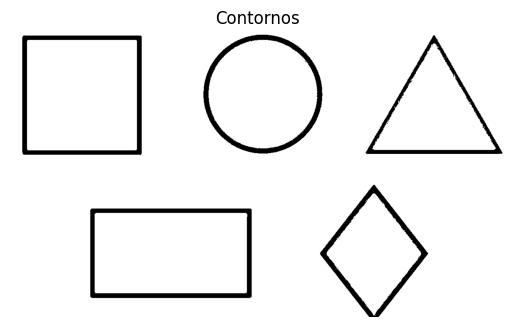

In [220]:
contornos, hierarchy = cv2.findContours(
    imagen_binaria,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []

for c in contornos:
    area = cv2.contourArea(c)
    if area > 1000:
        contornos_filtrados.append(c)

show_image(cv2.drawContours(imagen_binaria_umbral_adaptativo, contornos_filtrados, -1, (0,255,0), 3),"Contornos")



## Calculo de los momentos y centros de masa

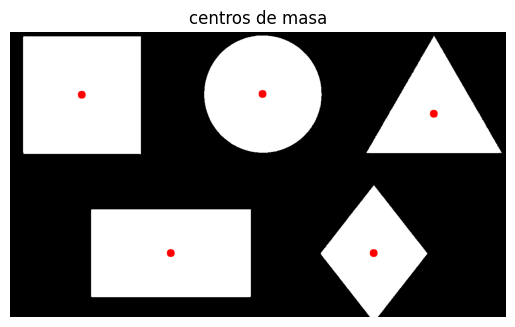

In [214]:
momentos = []

for i in contornos_filtrados:
  momentos.append( cv2.moments(i) )

centros_de_masa = []

for momento in momentos:
  if momento['m00'] != 0:
    cx = int(momento['m10'] / momento['m00'])
    cy = int(momento['m01'] / momento['m00'])

    centros_de_masa.append([cx,cy])

#print(centros_de_masa)

imagen_centros_de_masa = cv2.cvtColor(imagen_binaria, cv2.COLOR_GRAY2BGR)

for (cx, cy) in centros_de_masa:
    cv2.circle(imagen_centros_de_masa, (cx, cy), 10, (255, 0, 0), -1)

show_image(imagen_centros_de_masa, "centros de masa")

## Bounding boxes

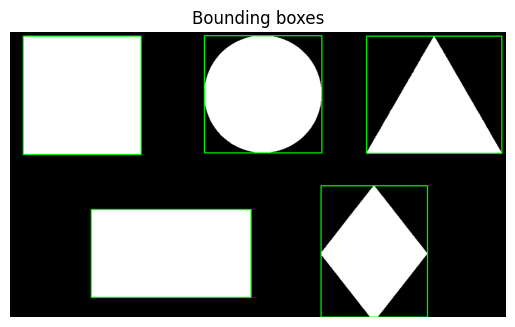

In [215]:
imagen_boxes = cv2.cvtColor(imagen_binaria, cv2.COLOR_GRAY2BGR)

for contorno in contornos_filtrados:
  x, y, w, h = cv2.boundingRect(contorno)

  cv2.rectangle(imagen_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

show_image(imagen_boxes, "Bounding boxes")

In [216]:
areas = []
perimetros = []

for contorno in contornos_filtrados:
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)

    if area > 50:
        areas.append(area)
        perimetros.append(perimetro)

num_formas = len(areas)

area_promedio = sum(areas) / num_formas if num_formas > 0 else 0
perimetro_promedio = sum(perimetros) / num_formas if num_formas > 0 else 0

print()

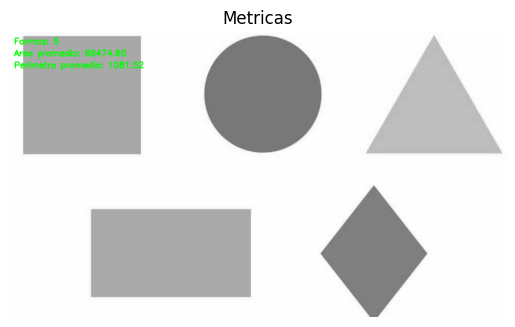

In [217]:
imagen_metricas = cv2.cvtColor(imagen_gris, cv2.COLOR_GRAY2BGR)

texto1 = f"Formas: {num_formas}"
texto2 = f"Area promedio: {area_promedio:.2f}"
texto3 = f"Perimetro promedio: {perimetro_promedio:.2f}"

cv2.putText(imagen_metricas, texto1, (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

cv2.putText(imagen_metricas, texto2, (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

cv2.putText(imagen_metricas, texto3, (10, 90),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

show_image(imagen_metricas, "Metricas")